<a href="https://colab.research.google.com/github/hoapp07/PhuHoa_AI_UEH/blob/main/appgiaxe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Đọc file
df = pd.read_excel('dataxe.xlsx', sheet_name='DuLieuXe_Cleaned')
df.head()

,Hãng xe,Dòng xe,Năm sản xuất,Số km đã chạy (ODO),Khu vực bán (Hồ Chí Minh),Tình trạng xe %,Giá bán,Đã thay phụ tùng chưa ?
0,Honda,SH,2021,12000,Quận 7,99,68500000,Chưa thay
1,Honda,Dream,2017,25000,Quận Tân Phú,90,12500000,Chưa thay
2,Honda,Vision,2020,15000,Quận Gò Vấp,99,28800000,Chưa thay
3,Honda,Future,2016,42000,Quận Tân Phú,85,17000000,Đã thay
4,Honda,Lead,2007,70000,Huyện Hóc Môn,80,6700000,Đã thay


In [2]:
# Đổi tên cột cho dễ dùng
df.columns = ['Hang_xe', 'Dong_xe', 'Nam_sx', 'ODO', 'Khu_vuc', 'Tinh_trang', 'Gia_ban', 'Thay_phu_tung']

# Sửa lỗi ODO bị dấu phẩy thành số
df['ODO'] = df['ODO'].astype(str).str.replace(',', '.').astype(float)

# Chuẩn hóa tên Hãng (viết hoa/thường)
df['Hang_xe'] = df['Hang_xe'].str.strip().str.capitalize()
# Sửa một số tên cụ thể nếu cần, ví dụ:
df['Hang_xe'] = df['Hang_xe'].replace({'Sym': 'SYM', 'Detech': 'Detech', 'Moka': 'Moka', 'Peugeot': 'Peugeot'})

# Chuẩn hóa tên dòng xe
df['Dong_xe'] = df['Dong_xe'].str.strip()
df['Dong_xe'] = df['Dong_xe'].replace({
    'Air blade': 'Air Blade', 'Airblade': 'Air Blade', 'AirBlade': 'Air Blade',
    'Honda AirBlade': 'Air Blade', 'LEAD': 'Lead', 'Winner X': 'Winner',
    'Winner V1': 'Winner', 'Visson': 'Vision'
})

# Xem lại dữ liệu sau khi sửa
print("Số dòng dữ liệu:", len(df))
df.head()

Số dòng dữ liệu: 243


,Hang_xe,Dong_xe,Nam_sx,ODO,Khu_vuc,Tinh_trang,Gia_ban,Thay_phu_tung
0,Honda,SH,2021,12000.0,Quận 7,99,68500000,Chưa thay
1,Honda,Dream,2017,25000.0,Quận Tân Phú,90,12500000,Chưa thay
2,Honda,Vision,2020,15000.0,Quận Gò Vấp,99,28800000,Chưa thay
3,Honda,Future,2016,42000.0,Quận Tân Phú,85,17000000,Đã thay
4,Honda,Lead,2007,70000.0,Huyện Hóc Môn,80,6700000,Đã thay


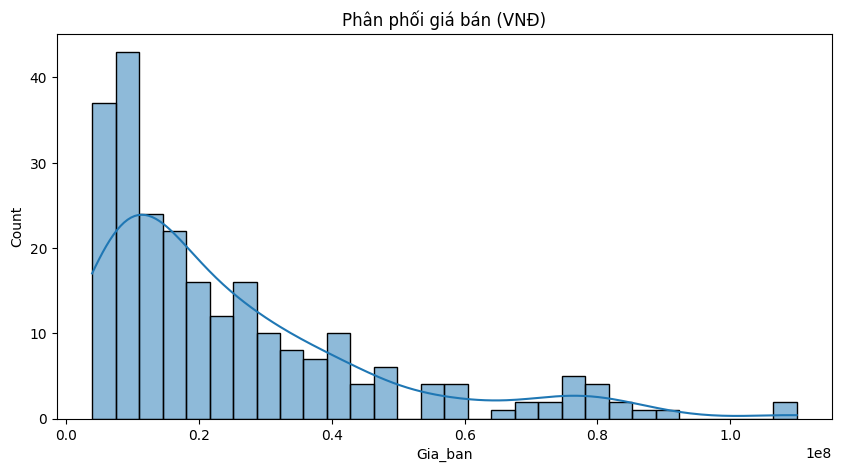

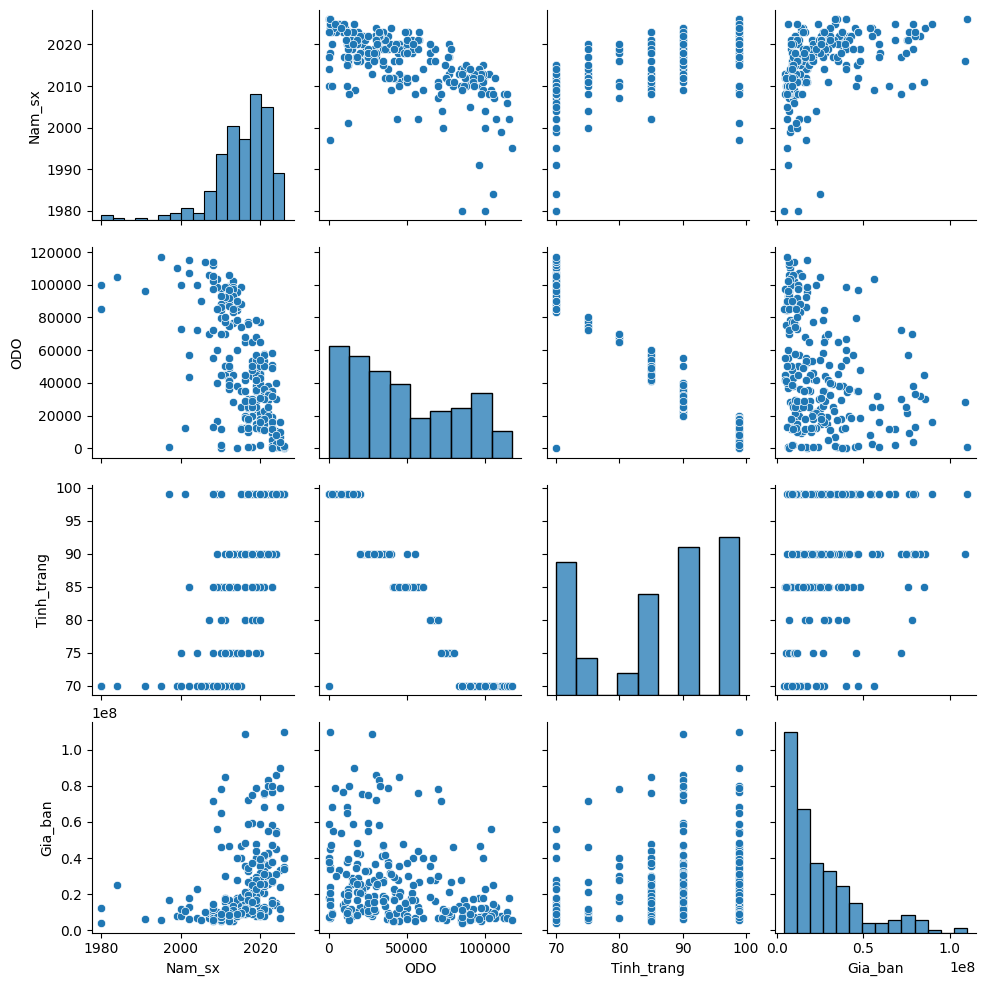

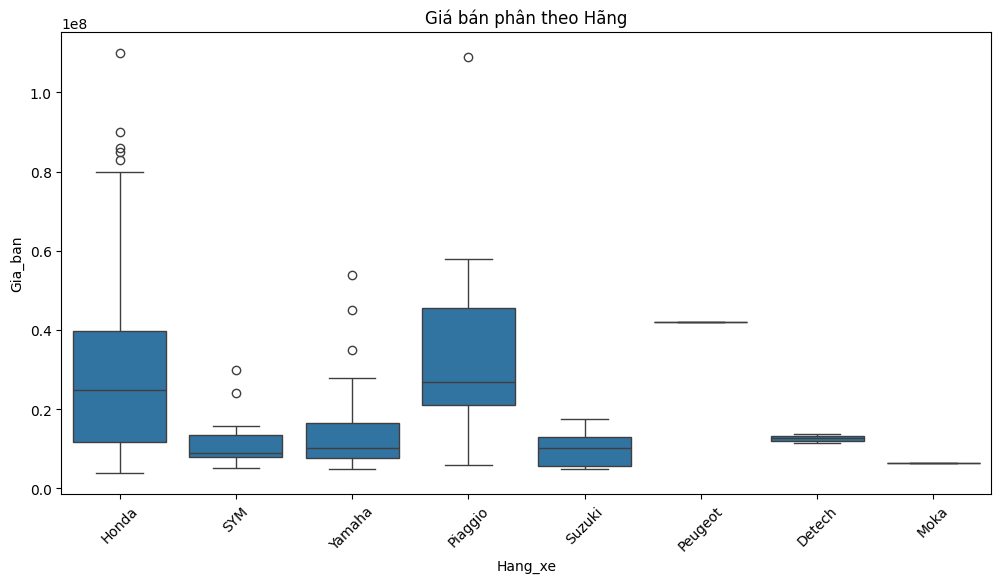

In [3]:
# 1. Phân phối giá
plt.figure(figsize=(10,5))
sns.histplot(df['Gia_ban'], bins=30, kde=True)
plt.title('Phân phối giá bán (VNĐ)')
plt.show()

# 2. Tương quan giữa các biến số
numeric_cols = ['Nam_sx', 'ODO', 'Tinh_trang', 'Gia_ban']
sns.pairplot(df[numeric_cols])
plt.show()

# 3. Giá theo Hãng xe
plt.figure(figsize=(12,6))
sns.boxplot(x='Hang_xe', y='Gia_ban', data=df)
plt.xticks(rotation=45)
plt.title('Giá bán phân theo Hãng')
plt.show()

In [4]:
# Tạo cột Tuổi xe
df['Tuoi_xe'] = 2026 - df['Nam_sx']

# Mã hóa các cột chữ thành số (để máy học hiểu)
categorical_cols = ['Hang_xe', 'Dong_xe', 'Khu_vuc', 'Thay_phu_tung']
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[categorical_cols] = encoder.fit_transform(df[categorical_cols])

# Lưu bộ mã hóa để dùng cho app sau này
joblib.dump(encoder, 'encoder.pkl')

# Xác định đầu vào (X) và đầu ra (y)
X = df.drop(['Gia_ban', 'Nam_sx'], axis=1)  # Bỏ cột năm gốc
y = df['Gia_ban']
print("Kích thước dữ liệu đầu vào:", X.shape)
X.head()

Kích thước dữ liệu đầu vào: (243, 7)


,Hang_xe,Dong_xe,ODO,Khu_vuc,Tinh_trang,Thay_phu_tung,Tuoi_xe
0,1.0,32.0,12000.0,25.0,99,1.0,5
1,1.0,7.0,25000.0,49.0,90,1.0,9
2,1.0,44.0,15000.0,40.0,99,1.0,6
3,1.0,13.0,42000.0,49.0,85,0.0,10
4,1.0,21.0,70000.0,3.0,80,0.0,19


In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale các cột số (đưa về cùng khoảng, giúp mô hình tốt hơn)
scaler = StandardScaler()
num_cols = ['ODO', 'Tinh_trang', 'Tuoi_xe']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Lưu scaler
joblib.dump(scaler, 'scaler.pkl')
print("Đã scale xong.")

Đã scale xong.


In [6]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"--- {name} ---")
    print(f"MAE  (Sai số tuyệt đối TB): {mae:,.0f} VND")
    print(f"RMSE (Sai số bình phương TB): {rmse:,.0f} VND")
    print(f"R²   (Độ chính xác): {r2:.3f}\n")

--- Linear Regression ---
MAE  (Sai số tuyệt đối TB): 13,972,389 VND
RMSE (Sai số bình phương TB): 18,135,567 VND
R²   (Độ chính xác): 0.114

--- Random Forest ---
MAE  (Sai số tuyệt đối TB): 9,555,960 VND
RMSE (Sai số bình phương TB): 13,310,081 VND
R²   (Độ chính xác): 0.523

--- Gradient Boosting ---
MAE  (Sai số tuyệt đối TB): 10,279,301 VND
RMSE (Sai số bình phương TB): 14,082,722 VND
R²   (Độ chính xác): 0.466



In [7]:
# Tuning nhẹ
param_grid = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
rf = RandomForestRegressor(random_state=42)
grid = GridSearchCV(rf, param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_

# Đánh giá mô hình tốt nhất
y_pred_best = best_model.predict(X_test)
print("=== Mô hình tối ưu ===")
print(f"MAE : {mean_absolute_error(y_test, y_pred_best):,.0f} VND")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):,.0f} VND")
print(f"R²  : {r2_score(y_test, y_pred_best):.3f}")

# Lưu model
joblib.dump(best_model, 'best_model.pkl')

=== Mô hình tối ưu ===
MAE : 9,612,745 VND
RMSE: 13,388,468 VND
R²  : 0.517


['best_model.pkl']

In [8]:
from google.colab import files
files.download('best_model.pkl')
files.download('encoder.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>